<a href="https://colab.research.google.com/github/amina-safrin/DataScience_Lab/blob/main/program9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Data Loading

In [4]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df_cancer = pd.DataFrame(data.data, columns=data.feature_names)
df_cancer['diagnosis'] = data.target

print("Breast Cancer dataset loaded successfully!")
print("First 5 rows of the dataset:")
print(df_cancer.head())
print("\nDataset info:")
df_cancer.info()

Breast Cancer dataset loaded successfully!
First 5 rows of the dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dime

In [5]:
df_cancer.to_csv('Breast_Cancer.csv', index=False)
print("Dataset saved to 'Breast_Cancer.csv'")

Dataset saved to 'Breast_Cancer.csv'


### 2. Data Preprocessing, Exploratory Data Analysis (EDA) and Model Training

Dataset 'Breast_Cancer.csv' loaded successfully.

--- 1. Basic EDA ---
First five records:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

 

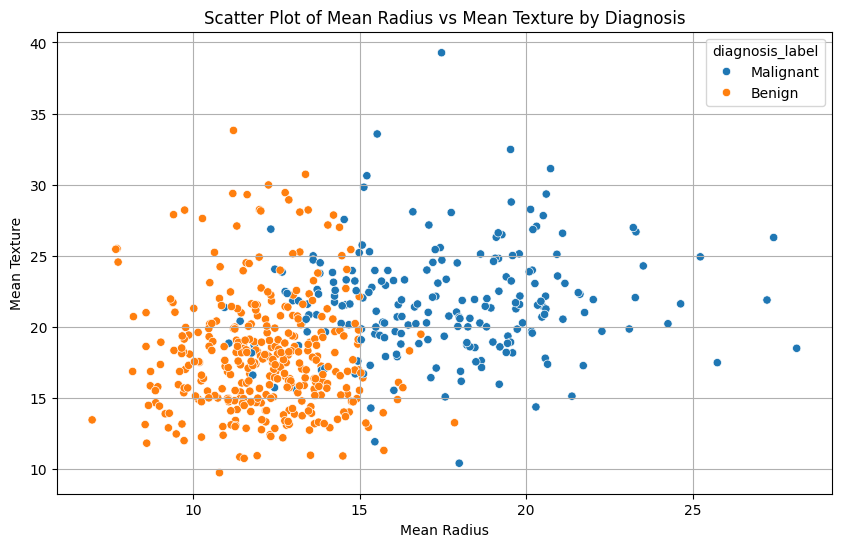

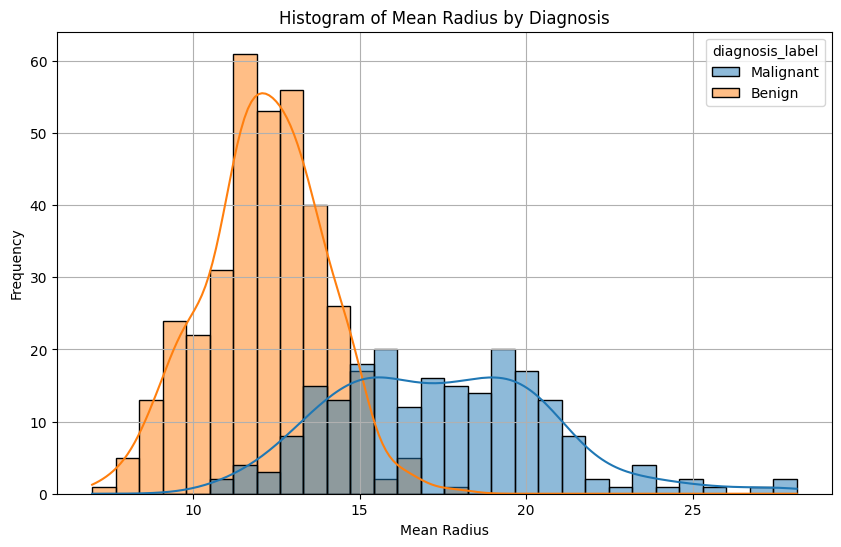

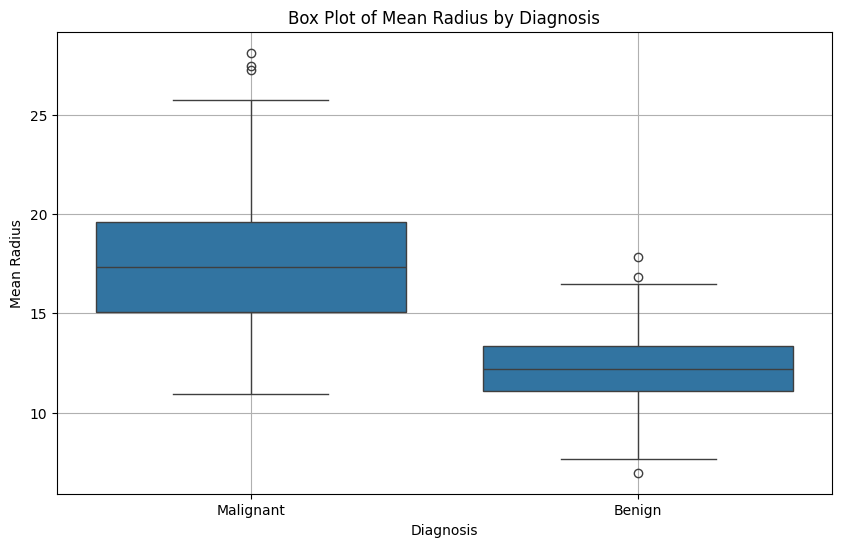

--- 3. Gaussian Naïve Bayes Classification ---
--- 4. Display Classification Report and Accuracy ---
Classification Report:
              precision    recall  f1-score   support

   Malignant       1.00      0.93      0.96        43
      Benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Accuracy: 0.9737


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

try:
    df = pd.read_csv('Breast_Cancer.csv')
    print("Dataset 'Breast_Cancer.csv' loaded successfully.\n")
except FileNotFoundError:
    print("Error: 'Breast_Cancer.csv' not found. Please ensure it's in the Colab environment.")
    print("Skipping further operations as the dataset is not available.")
    df = None

if df is not None:
    df['diagnosis_label'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

    print("--- 1. Basic EDA ---")

    print("First five records:")
    print(df.head())
    print("\n")

    print("Missing values per column:")
    print(df.isnull().sum())
    print("\n")

    print("Descriptive statistics:")
    print(df.describe())
    print("\n")

    print("Diagnosis distribution:")
    print(df['diagnosis_label'].value_counts())
    print("\n")

    print("--- 2. Plotting ---")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='diagnosis_label')
    plt.title('Scatter Plot of Mean Radius vs Mean Texture by Diagnosis')
    plt.xlabel('Mean Radius')
    plt.ylabel('Mean Texture')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='mean radius', kde=True, bins=30, hue='diagnosis_label')
    plt.title('Histogram of Mean Radius by Diagnosis')
    plt.xlabel('Mean Radius')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='diagnosis_label', y='mean radius')
    plt.title('Box Plot of Mean Radius by Diagnosis')
    plt.xlabel('Diagnosis')
    plt.ylabel('Mean Radius')
    plt.grid(True)
    plt.show()

    print("--- 3. Gaussian Naïve Bayes Classification ---")

    X = df.drop(columns=['diagnosis', 'diagnosis_label'], errors='ignore')
    y = df['diagnosis']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    gnb = GaussianNB()
    gnb.fit(X_train, y_train)

    y_pred = gnb.predict(X_test)

    print("--- 4. Display Classification Report and Accuracy ---")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")
else:
    print("Cannot proceed with EDA, plotting, and model training as dataset was not loaded.")

### 3. Iris Flower Analysis and Naïve Bayes Classification


--- Iris Flower Analysis ---
Dataset 'Iris.csv' loaded successfully.

--- 1. Basic EDA for Iris Dataset ---
First five records:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


Descriptive statistics:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667

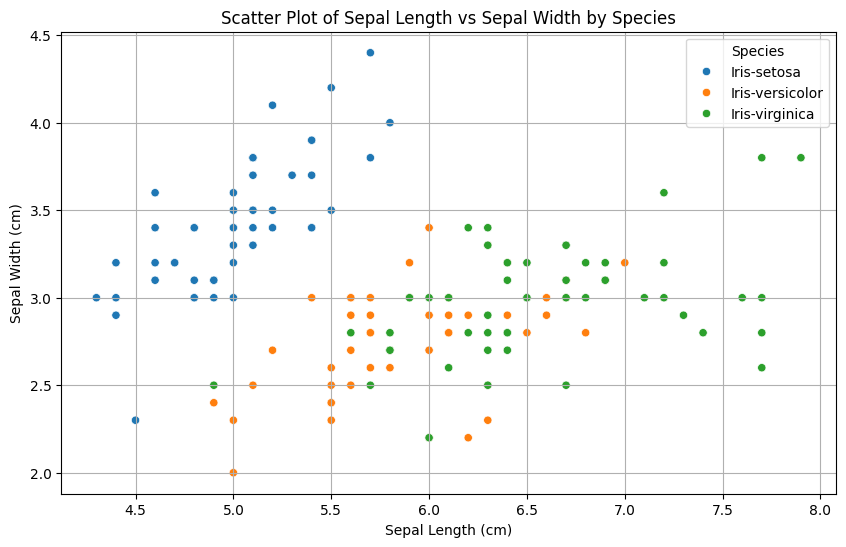

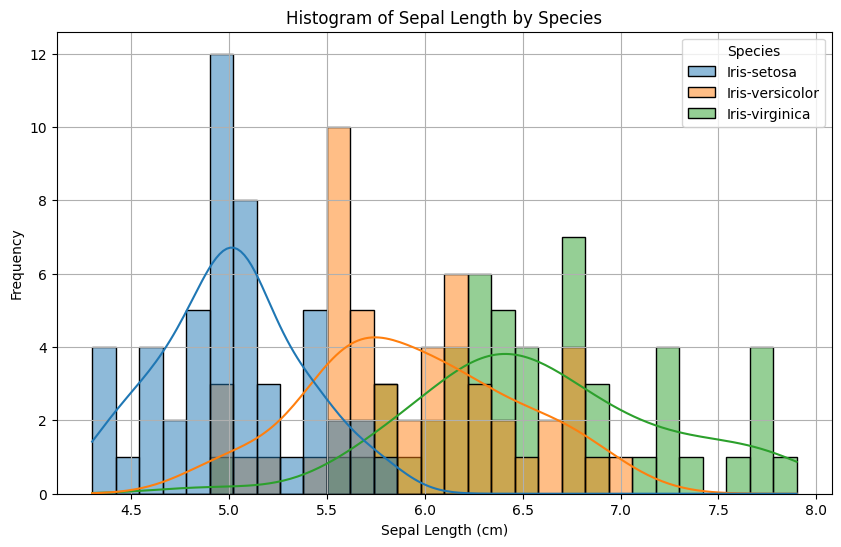

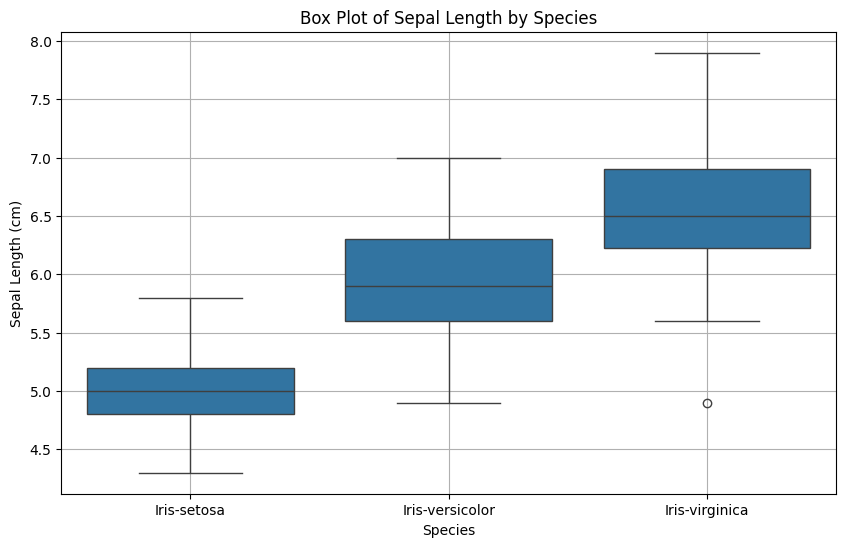

--- 3. Gaussian Naïve Bayes Classification for Iris Dataset ---
--- 4. Display Classification Report and Accuracy for Iris Dataset ---
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Accuracy: 1.0000


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

print("\n--- Iris Flower Analysis ---")

try:
    df_iris = pd.read_csv('Iris.csv')
    print("Dataset 'Iris.csv' loaded successfully.\n")
except FileNotFoundError:
    print("Error: 'Iris.csv' not found. Please ensure it's in the Colab environment.")
    print("Skipping further operations for Iris dataset.")
    df_iris = None

if df_iris is not None:
    print("--- 1. Basic EDA for Iris Dataset ---")

    print("First five records:")
    print(df_iris.head())
    print("\n")

    print("Missing values per column:")
    print(df_iris.isnull().sum())
    print("\n")

    print("Descriptive statistics:")
    print(df_iris.describe())
    print("\n")

    print("Species distribution:")
    print(df_iris['Species'].value_counts())
    print("\n")

    print("--- 2. Plotting for Iris Dataset ---")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_iris, x='SepalLengthCm', y='SepalWidthCm', hue='Species')
    plt.title('Scatter Plot of Sepal Length vs Sepal Width by Species')
    plt.xlabel('Sepal Length (cm)')
    plt.ylabel('Sepal Width (cm)')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_iris, x='SepalLengthCm', kde=True, bins=30, hue='Species')
    plt.title('Histogram of Sepal Length by Species')
    plt.xlabel('Sepal Length (cm)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_iris, x='Species', y='SepalLengthCm')
    plt.title('Box Plot of Sepal Length by Species')
    plt.xlabel('Species')
    plt.ylabel('Sepal Length (cm)')
    plt.grid(True)
    plt.show()

    print("--- 3. Gaussian Naïve Bayes Classification for Iris Dataset ---")

    X_iris = df_iris.drop(columns=['Id', 'Species'], errors='ignore')
    y_iris = df_iris['Species']

    X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

    gnb_iris = GaussianNB()
    gnb_iris.fit(X_train_iris, y_train_iris)

    y_pred_iris = gnb_iris.predict(X_test_iris)

    print("--- 4. Display Classification Report and Accuracy for Iris Dataset ---")

    print("Classification Report:")
    print(classification_report(y_test_iris, y_pred_iris))

    accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)
    print(f"\nAccuracy: {accuracy_iris:.4f}")
else:
    print("Cannot proceed with Iris analysis as dataset was not loaded.")

### 4. Data Cleaning for Wine Quality Dataset

In [11]:
import pandas as pd

# Assuming df_wine is already loaded from the previous cell
if 'df_wine' in locals() and df_wine is not None:
    print("--- Data Cleaning for Wine Quality Dataset ---")

    # Check for missing values (re-confirming as part of cleaning process)
    print("Missing values before cleaning:")
    print(df_wine.isnull().sum())
    print("\n")

    # Check for duplicate rows
    print(f"Shape of DataFrame before removing duplicates: {df_wine.shape}")
    duplicates_count = df_wine.duplicated().sum()
    if duplicates_count > 0:
        print(f"Found {duplicates_count} duplicate rows. Removing them...")
        df_wine.drop_duplicates(inplace=True)
        print(f"Shape of DataFrame after removing duplicates: {df_wine.shape}")
    else:
        print("No duplicate rows found.")

    print("\nData cleaning complete.")
else:
    print("Wine Quality DataFrame (df_wine) not found. Please ensure it was loaded correctly.")

--- Data Cleaning for Wine Quality Dataset ---
Missing values before cleaning:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


Shape of DataFrame before removing duplicates: (1143, 13)
No duplicate rows found.

Data cleaning complete.



--- Wine Quality Analysis ---
Dataset 'WineQT.csv' loaded successfully.

--- 1. Basic EDA for Wine Quality Dataset ---
First five records:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.

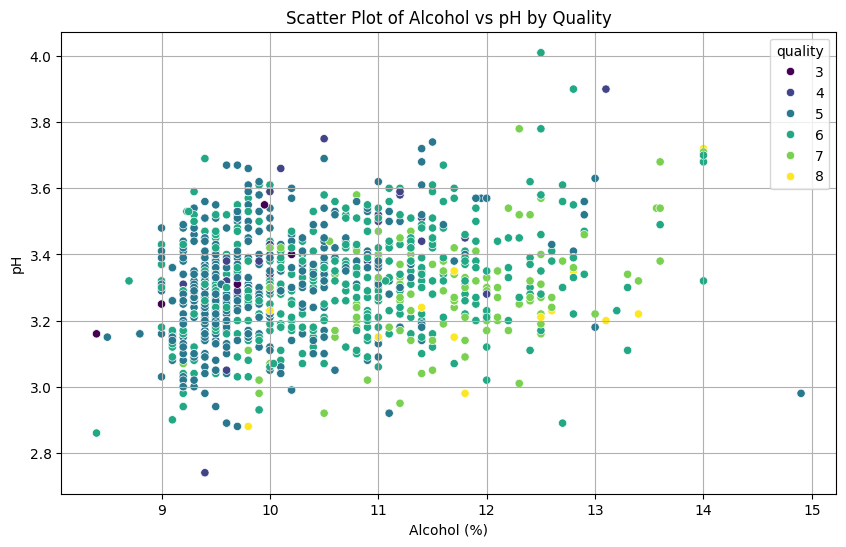

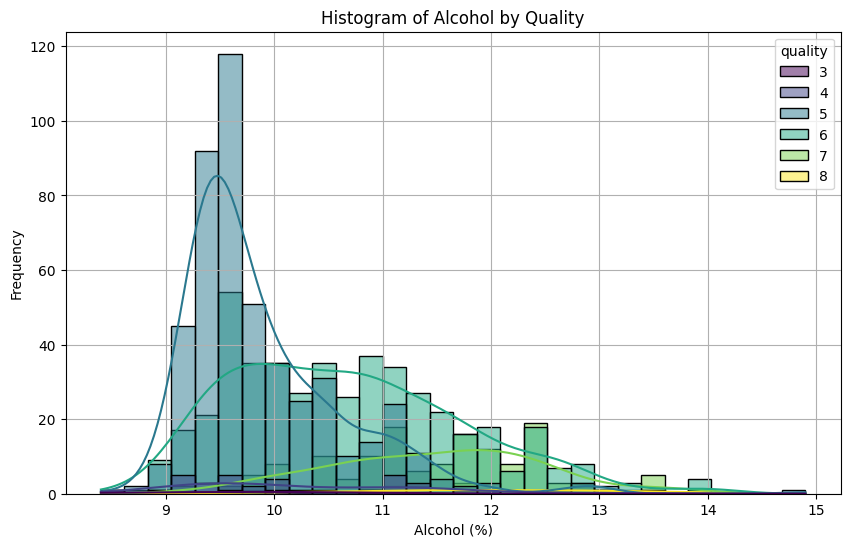

/tmp/ipykernel_2184/4027356732.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_wine, x='quality', y='alcohol', palette='viridis')


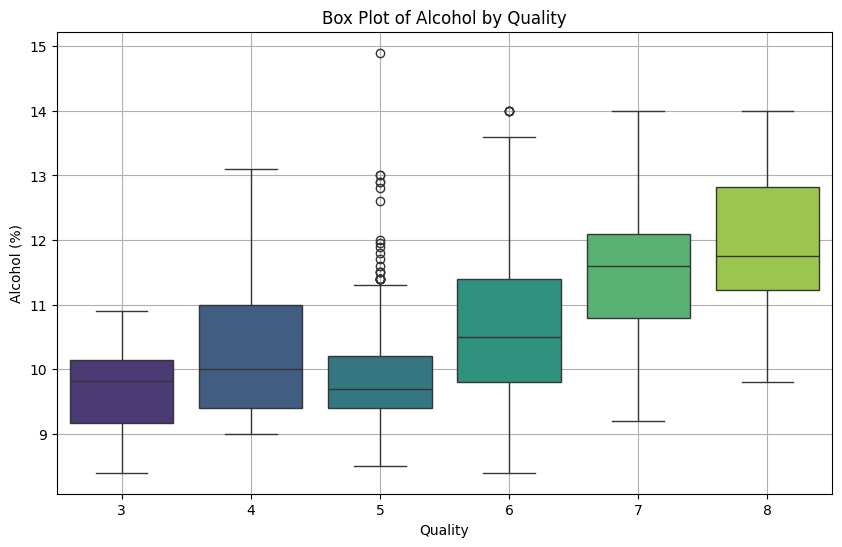

--- 3. Gaussian Naïve Bayes Classification for Wine Quality Dataset ---
--- 4. Display Classification Report and Accuracy for Wine Quality Dataset ---
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         6
           5       0.74      0.52      0.61        96
           6       0.57      0.69      0.62        99
           7       0.50      0.58      0.54        26
           8       0.00      0.00      0.00         2

    accuracy                           0.58       229
   macro avg       0.30      0.30      0.29       229
weighted avg       0.61      0.58      0.59       229


Accuracy: 0.5808


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

print("\n--- Wine Quality Analysis ---")

# Load the Wine Quality dataset
try:
    df_wine = pd.read_csv('WineQT.csv')
    print("Dataset 'WineQT.csv' loaded successfully.\n")
except FileNotFoundError:
    print("Error: 'WineQT.csv' not found. Please ensure it's in the Colab environment.")
    print("Skipping further operations for Wine Quality dataset.")
    df_wine = None

# Proceed only if the dataset was loaded successfully
if df_wine is not None:
    # 1. Basic EDA for Wine Quality Dataset
    print("--- 1. Basic EDA for Wine Quality Dataset ---")

    # Display the first five records
    print("First five records:")
    print(df_wine.head())
    print("\n")

    # Display missing values per column
    print("Missing values per column:")
    print(df_wine.isnull().sum())
    print("\n")

    # Display descriptive statistics
    print("Descriptive statistics:")
    print(df_wine.describe())
    print("\n")

    # Display quality distribution
    print("Quality distribution:")
    print(df_wine['quality'].value_counts().sort_index())
    print("\n")

    # 2. Plotting for Wine Quality Dataset
    print("--- 2. Plotting for Wine Quality Dataset ---")

    # Scatter plot of alcohol vs pH by quality
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_wine, x='alcohol', y='pH', hue='quality', palette='viridis')
    plt.title('Scatter Plot of Alcohol vs pH by Quality')
    plt.xlabel('Alcohol (%)')
    plt.ylabel('pH')
    plt.grid(True)
    plt.show()

    # Histogram of alcohol by quality
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_wine, x='alcohol', kde=True, bins=30, hue='quality', palette='viridis')
    plt.title('Histogram of Alcohol by Quality')
    plt.xlabel('Alcohol (%)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    # Box plot of alcohol by quality
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_wine, x='quality', y='alcohol', palette='viridis')
    plt.title('Box Plot of Alcohol by Quality')
    plt.xlabel('Quality')
    plt.ylabel('Alcohol (%)')
    plt.grid(True)
    plt.show()

    # 3. Gaussian Naïve Bayes Classification for Wine Quality Dataset
    print("--- 3. Gaussian Naïve Bayes Classification for Wine Quality Dataset ---")

    # Prepare features (X) and target (y)
    # Drop 'Id' and 'quality' to use other numerical features for prediction
    X_wine = df_wine.drop(columns=['Id', 'quality'], errors='ignore')
    y_wine = df_wine['quality']

    # Split the data into training and testing sets (80:20 split)
    X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)

    # Initialize and train the Gaussian Naïve Bayes model
    gnb_wine = GaussianNB()
    gnb_wine.fit(X_train_wine, y_train_wine)

    # Make predictions on the test set
    y_pred_wine = gnb_wine.predict(X_test_wine)

    # 4. Display Classification Report and Accuracy for Wine Quality Dataset
    print("--- 4. Display Classification Report and Accuracy for Wine Quality Dataset ---")

    # Display the classification report
    print("Classification Report:")
    print(classification_report(y_test_wine, y_pred_wine, zero_division=0))

    # Display the accuracy
    accuracy_wine = accuracy_score(y_test_wine, y_pred_wine)
    print(f"\nAccuracy: {accuracy_wine:.4f}")
else:
    print("Cannot proceed with Wine Quality analysis as dataset was not loaded.")